In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from keras.preprocessing.image import array_to_img, img_to_array, load_img
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential, save_model, load_model
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Activation, Dropout
from keras.utils import plot_model
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.figure_factory as ff

In [3]:
images=[]
labels=[]

# oop over top 10 folders
for directory in os.listdir('D:/Task 04/HandGesture'):
    for subdir in os.listdir(os.path.join('D:/Task 04/HandGesture',directory)):
#         if directory=='01':
#             labels.append(subdir)
        for image in os.listdir(os.path.join('D:/Task 04/HandGesture',directory, subdir)):
            img_path = os.path.join('D:/Task 04/HandGesture', directory, subdir, image)
            images.append(img_path)
            labels.append(subdir)

In [4]:
df = pd.DataFrame({'Image':images,'Label':labels})
df.tail()

,Image,Label
5238,D:/Task 04/HandGesture\images\up\9956.jpg,up
5239,D:/Task 04/HandGesture\images\up\9964.jpg,up
5240,D:/Task 04/HandGesture\images\up\9974.jpg,up
5241,D:/Task 04/HandGesture\images\up\9985.jpg,up
5242,D:/Task 04/HandGesture\images\up\9996.jpg,up


In [6]:
print(df.shape)
print(df.index)

(5243, 2)
RangeIndex(start=0, stop=5243, step=1)


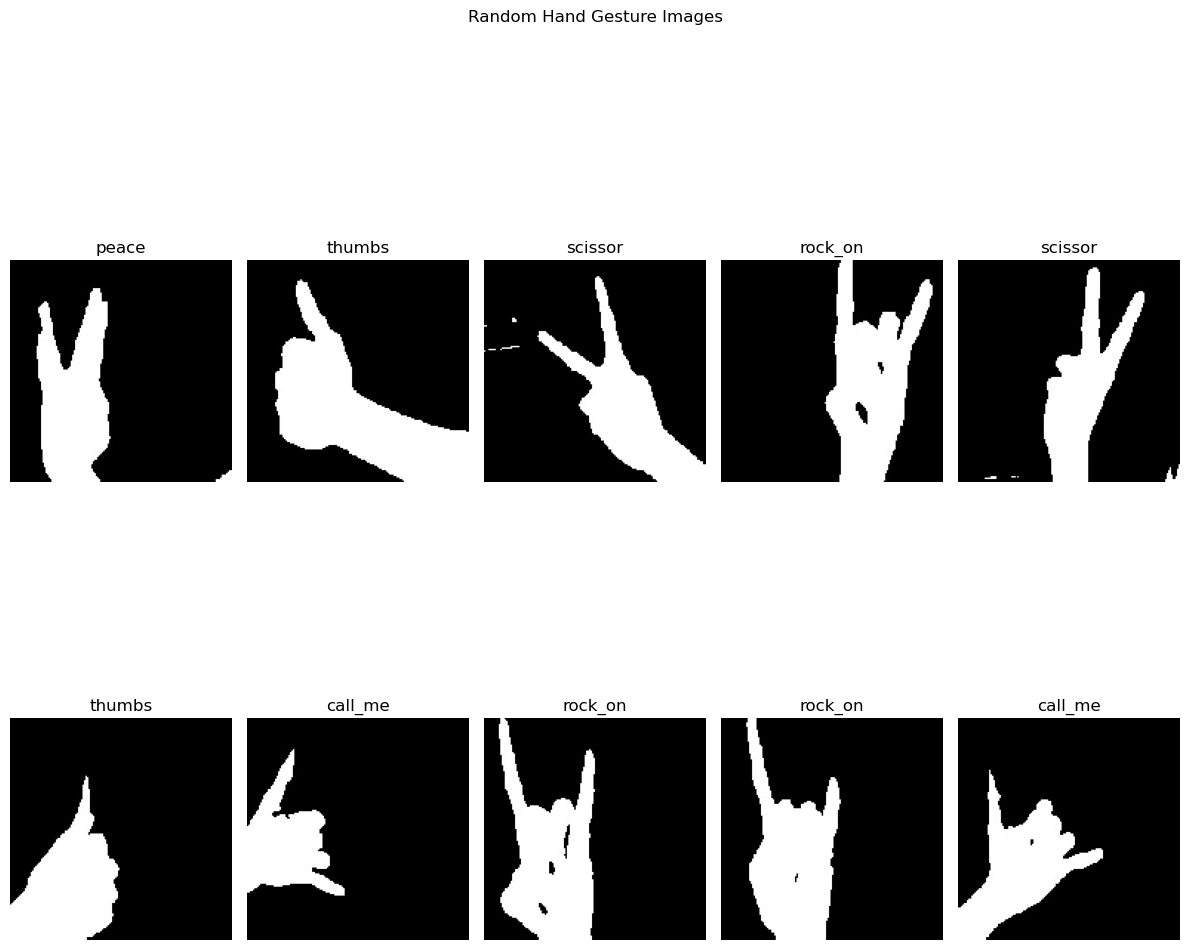

In [7]:
df_img = df['Image']
df_label = df['Label']

nrows = 2
ncols = 5

fig, axx = plt.subplots(nrows, ncols, figsize=(12, 12))
fig.suptitle("Random Hand Gesture Images")

for i in range(nrows):
    for j in range(ncols):
        # Generate a valid random index
        n = np.random.randint(len(df))

        # Load image
        img = load_img(df_img.iloc[n], target_size=(150, 150))
        img = img_to_array(img)
        img = img / 255.0

        # Get label
        label = df_label.iloc[n]

        # Display image
        axx[i, j].imshow(img)
        axx[i, j].set_title(label)
        axx[i, j].axis("off")  # Hide axes

plt.tight_layout()
plt.show()

In [8]:
x_train,x = train_test_split(df, test_size = 0.3)
# train_x, test_x, train_y, test_y = train_test_split(images,labels,test_size=0.2)
x_valid,x_test = train_test_split(x,test_size=0.5)
x_train.info()
x_valid.info()
x_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3670 entries, 2569 to 1725
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Image   3670 non-null   object
 1   Label   3670 non-null   object
dtypes: object(2)
memory usage: 86.0+ KB
<class 'pandas.core.frame.DataFrame'>
Index: 786 entries, 4803 to 4405
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Image   786 non-null    object
 1   Label   786 non-null    object
dtypes: object(2)
memory usage: 18.4+ KB
<class 'pandas.core.frame.DataFrame'>
Index: 787 entries, 4861 to 2242
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Image   787 non-null    object
 1   Label   787 non-null    object
dtypes: object(2)
memory usage: 18.4+ KB


In [9]:
#data augmentation
datagen = ImageDataGenerator(
        rotation_range=10, # rotation
        width_shift_range=0.2, # horizontal shift
        height_shift_range=0.2, # vertical shift
        zoom_range=0.2, # zoom
        horizontal_flip=True, # horizontal flip
        brightness_range=[0.2,1.2]) # brightness


train_datagen = ImageDataGenerator(rescale=1.0/255,
                                 shear_range=0.2,
                                 zoom_range=0.2,
                                 horizontal_flip=True)
validate_datagen = ImageDataGenerator(rescale=1.0/255)

In [10]:
b_size =1
train_generator = train_datagen.flow_from_dataframe(dataframe=x_train,x_col="Image",y_col='Label',class_mode="categorical",target_size=(150,150),batch_size=b_size,seed=2020, shuffle=True)
valid_generator = validate_datagen.flow_from_dataframe(dataframe=x_valid,x_col="Image",y_col='Label',class_mode="categorical",target_size=(150,150),batch_size=b_size,seed=2020, shuffle=False)
     

Found 3670 validated image filenames belonging to 10 classes.
Found 786 validated image filenames belonging to 10 classes.


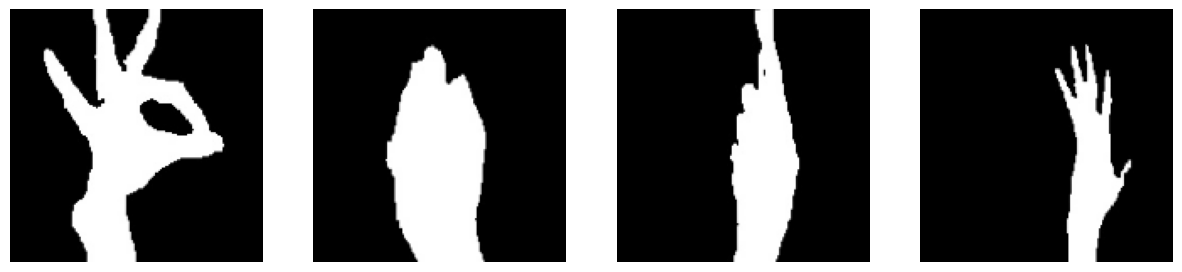

In [11]:
#plot some augmented images
fig,axx = plt.subplots(nrows=1,ncols=4, figsize=(15,15))

for i in range(4):
    image = next(train_generator)[0].astype('float64')
    image = np.squeeze(image)
    axx[i].imshow(image)
    axx[i].axis('off')

In [12]:
model = Sequential()
model.add(Conv2D(32,(3,3), input_shape=(150,150,3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(32,(3,3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(64,(3,3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# on top of the model we add 2 fully connected layers to flatten the 3D feature maps into 10 feature victors representing 10 differnet categories of hanf geatures
model.add(Flatten())
model.add(Dense(64))
model.add(Activation('relu'))
model.add(Dropout(0.2))
model.add(Dense(10))
model.add(Activation('softmax'))

model.compile(loss=tf.keras.losses.CategoricalCrossentropy(from_logits=False),
             optimizer = 'adam',
             metrics=[tf.keras.metrics.CategoricalAccuracy()])
model.summary()

c:\Users\rajes\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 148, 148, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 72, 72, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 34, 34, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18496)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,183,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,213,098 (4.63 MB)

 Trainable params: 1,213,098 (4.63 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
#train Test data in the model
history = model.fit(train_generator,
                   steps_per_epoch=2000//b_size,
                   epochs = 20,
                   validation_data = valid_generator,
                    validation_steps=800//b_size)

model.save('handG_R.h5')

Epoch 1/20
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 200s 96ms/step - categorical_accuracy: 0.3960 - loss: 1.7123 - val_categorical_accuracy: 0.7570 - val_loss: 0.7562
Epoch 2/20
   1/2000 ━━━━━━━━━━━━━━━━━━━━ 2:08 64ms/step - categorical_accuracy: 1.0000 - loss: 0.6328

c:\Users\rajes\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


2000/2000 ━━━━━━━━━━━━━━━━━━━━ 99s 49ms/step - categorical_accuracy: 0.7251 - loss: 0.8357 - val_categorical_accuracy: 0.8181 - val_loss: 0.5426
Epoch 3/20
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 105s 52ms/step - categorical_accuracy: 0.7790 - loss: 0.6564 - val_categorical_accuracy: 0.8664 - val_loss: 0.4360
Epoch 4/20
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 96s 48ms/step - categorical_accuracy: 0.8473 - loss: 0.4575 - val_categorical_accuracy: 0.9135 - val_loss: 0.3216
Epoch 5/20
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 110s 55ms/step - categorical_accuracy: 0.8470 - loss: 0.4799 - val_categorical_accuracy: 0.8969 - val_loss: 0.3755
Epoch 6/20
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 116s 58ms/step - categorical_accuracy: 0.8719 - loss: 0.4013 - val_categorical_accuracy: 0.9377 - val_loss: 0.2215
Epoch 7/20
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 272s 136ms/step - categorical_accuracy: 0.8885 - loss: 0.3350 - val_categorical_accuracy: 0.9262 - val_loss: 0.2500
Epoch 8/20
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 89s 44ms/step - categorical_

In [14]:
# display loss & accuracy
history.history

{'categorical_accuracy': [0.3959999978542328,
  0.7251496911048889,
  0.7789999842643738,
  0.847305417060852,
  0.847000002861023,
  0.8718562722206116,
  0.8884999752044678,
  0.9005988240242004,
  0.9004999995231628,
  0.9191616773605347,
  0.9204999804496765,
  0.9185628890991211,
  0.9279999732971191,
  0.93113774061203,
  0.9254999756813049,
  0.9293413162231445,
  0.9309999942779541,
  0.942514955997467,
  0.9415000081062317,
  0.9383233785629272],
 'loss': [1.7123178243637085,
  0.8357272148132324,
  0.656358003616333,
  0.45747944712638855,
  0.47988495230674744,
  0.40125951170921326,
  0.3349649906158447,
  0.2974715828895569,
  0.2984696924686432,
  0.2587442100048065,
  0.27908340096473694,
  0.28432029485702515,
  0.23772713541984558,
  0.2300563007593155,
  0.2321743369102478,
  0.24230018258094788,
  0.22617021203041077,
  0.18499088287353516,
  0.20170415937900543,
  0.18176093697547913],
 'val_categorical_accuracy': [0.7569974660873413,
  0.8180661797523499,
  0.86641

In [15]:
#visualize training loss & validation loss which indecates there is no overfitting
fig = go.Figure()
epochs = 20
fig.add_trace(go.Scatter(x=np.arange(0,epochs,1),
y=history.history['loss'],
mode='lines',
name=f'training loss',
marker_size=3,
line_color='blue'))
fig.add_trace(go.Scatter(x=np.arange(0, epochs, 1),
                         y=history.history['val_loss'],
                         mode='lines',
                         name=f'Validation loss',
                         line_color='grey'))
fig.update_layout(
                  title="CNN training loss",
                  xaxis_title="Epochs",
                  yaxis_title=f"CategoricalCrossentropy")

fig.update_layout({'plot_bgcolor': '#f2f8fd' ,
                   'paper_bgcolor': 'white',},
                   template='plotly_white')

In [16]:
#visualize training accuracy & validation accuracy
fig = go.Figure()
epochs = 20
fig.add_trace(go.Scatter(x=np.arange(0,epochs,1),
y=history.history['categorical_accuracy'],
mode='lines',
name=f'training accuracy',
marker_size=3,
line_color='blue'))
fig.add_trace(go.Scatter(x=np.arange(0, epochs, 1),
                         y=history.history['val_categorical_accuracy'],
                         mode='lines',
                         name=f'Validation accuracy',
                         line_color='grey'))
fig.update_layout(
                  title="CNN training accuracy",
                  xaxis_title="Epochs",
                  yaxis_title=f"CategoricalCrossentropy")

fig.update_layout({'plot_bgcolor': '#f2f8fd' ,
                   'paper_bgcolor': 'white',},
                   template='plotly_white')